# Frequency tracking with an adaptive window

A classic use case for a differentiable STFT: a signal whose instantaneous frequency changes over time (a chirp). A fixed-window STFT has to trade off time resolution against frequency resolution everywhere at once. Here we let `DSTFT` learn a time-varying window length that minimizes spectrogram entropy, and compare the resulting frequency-tracking accuracy against a fixed-window baseline — including cases where adaptivity does **not** help much, which is just as informative as cases where it does.

In [1]:
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(device, torch.__version__)
torch.manual_seed(1802)

%load_ext autoreload
%autoreload 2
%matplotlib inline

cpu 2.13.0+cu130


## 1. A synthetic chirp with known ground-truth frequency

Signal shape: torch.Size([1, 4000])


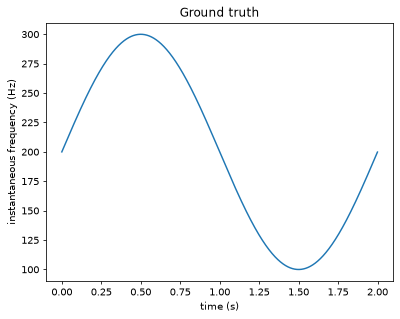

In [2]:
import matplotlib.pyplot as plt


plt.rcParams["figure.dpi"] = 70  # keep saved notebook outputs small

sr = 2_000.0  # Hz
duration = 2.0  # s
n_samples = int(sr * duration)
t = torch.arange(n_samples, dtype=dtype, device=device) / sr

# instantaneous frequency: a slow sinusoidal sweep between 100 Hz and 300 Hz
f_inst = 200.0 + 100.0 * torch.sin(2 * torch.pi * 0.5 * t)
phase = 2 * torch.pi * torch.cumsum(f_inst, dim=0) / sr
x = torch.cos(phase)[None, :]
x = x + 0.02 * torch.randn_like(x)

plt.plot(t.cpu(), f_inst.cpu())
plt.xlabel("time (s)")
plt.ylabel("instantaneous frequency (Hz)")
plt.title("Ground truth")
print(f"Signal shape: {x.shape}")

## 2. Loss and helper to read a frequency estimate off a spectrogram

In [3]:
def entropy_loss(x: torch.Tensor):
    """A simple loss function to encourage spectrogram sparsity."""
    x1 = torch.reshape(x, (x.shape[0], -1))  # B, N
    probs = torch.div(x1.T, x1.sum(dim=-1)).T  # B, N
    entropy = -(
        probs * torch.clamp(torch.log(probs), min=torch.finfo(x.dtype).min)
    ).sum(dim=-1)  # B
    return entropy.mean()


def track_frequency(spec: torch.Tensor, n_fft: int, sr: float) -> torch.Tensor:
    """Per-frame frequency estimate: argmax bin of the magnitude spectrogram."""
    bin_idx = spec[0].argmax(dim=0).float()  # [frames]
    return bin_idx * sr / n_fft

## 3. Fixed window baseline vs. learned time-varying window

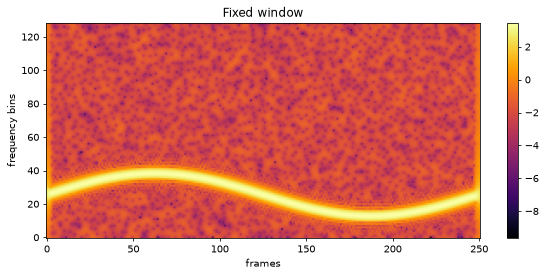

In [4]:
from dstft import DSTFT


n_fft = 256
win_length = 128
hop_length = 16
epochs = 3_000
lr = 1
patience = 9
factor = 0.1
threshold = 0.5


# --- fixed window baseline ---
dstft_fixed = DSTFT(
    win_length=win_length, n_fft=n_fft, hop_length=hop_length, window_mode="fixed"
)
dstft_fixed.initialize(x)
spec_fixed, _ = dstft_fixed(x)
dstft_fixed.plot_spec(spec_fixed, title="Fixed window")

f_hat_fixed = track_frequency(spec_fixed, n_fft, sr)

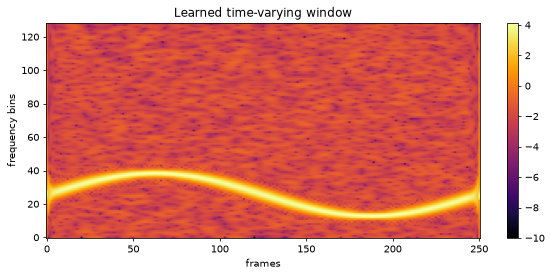

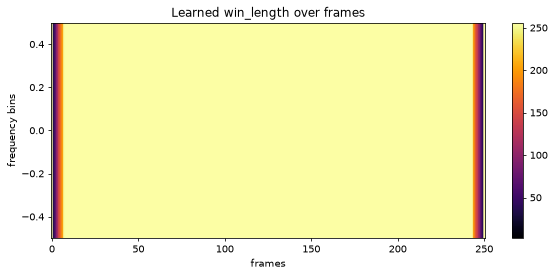

In [5]:
# --- time-varying learned window ---
dstft_time = DSTFT(
    win_length=win_length, n_fft=n_fft, hop_length=hop_length, window_mode="time"
)
dstft_time.initialize(x)
optimizer = torch.optim.Adam(dstft_time.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer, mode="min", factor=factor, patience=patience
)

for _ in range(epochs):
    optimizer.zero_grad(set_to_none=True)
    spec, _ = dstft_time(x)
    loss = entropy_loss(spec)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.detach())
    if optimizer.param_groups[0]["lr"] < threshold:
        break

spec_time, _ = dstft_time(x)
dstft_time.plot_spec(spec_time, title="Learned time-varying window")
dstft_time.plot_win_lengths(title="Learned win_length over frames")

f_hat_time = track_frequency(spec_time, n_fft, sr)

## 4. Comparing the tracked frequency to ground truth

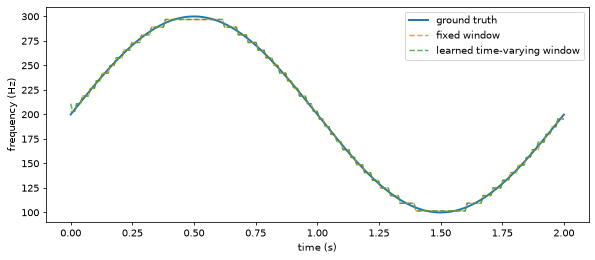

MSE (fixed window):          4.8 Hz^2
MSE (time-varying window):   5.3 Hz^2


In [6]:
frame_hop = float(dstft_fixed.hop_length.mean().item())
frame_t = torch.arange(f_hat_fixed.shape[0]) * frame_hop / sr
# nearest ground-truth sample for each frame center
gt_idx = (frame_t * sr).long().clamp(max=n_samples - 1)
f_gt = f_inst.cpu()[gt_idx]

plt.figure(figsize=(10, 4))
plt.plot(frame_t, f_gt, label="ground truth", linewidth=2)
plt.plot(frame_t, f_hat_fixed.cpu(), "--", label="fixed window", alpha=0.8)
plt.plot(
    frame_t,
    f_hat_time.detach().cpu(),
    "--",
    label="learned time-varying window",
    alpha=0.8,
)
plt.xlabel("time (s)")
plt.ylabel("frequency (Hz)")
plt.legend()
plt.show()

mse_fixed = torch.nn.functional.mse_loss(f_hat_fixed.cpu(), f_gt).item()
mse_time = torch.nn.functional.mse_loss(f_hat_time.detach().cpu(), f_gt).item()
print(f"MSE (fixed window):          {mse_fixed:.1f} Hz^2")
print(f"MSE (time-varying window):   {mse_time:.1f} Hz^2")

The frequency-bin resolution of a spectrogram is coarse by construction (`sr / n_fft` Hz per bin), so don't expect either estimate to be exact — the point of this notebook is the *relative* accuracy of the adaptive window against the fixed one, not absolute precision.

For a single, smoothly-swept tone like this one, a well-chosen fixed window is often already close to optimal, so the learned time-varying window may only match it, or even trail slightly behind (stochastic entropy-loss optimization is not guaranteed to align with tracking accuracy, which it never directly optimizes for). Adaptive windows earn their keep on signals whose time-frequency content genuinely varies in nature across time — like the slow-tone/fast-tone example in `window_modes.ipynb` — not on every signal indiscriminately. Try widening the sweep range (e.g. 50-500 Hz) or speeding up its rate to see the gap grow.